In [1]:
## importing libraries
import numpy as np                  # importing numpy for mathematical/numerical analysis
import pandas as pd                 # importing pandas for analyzing, manipulation or claeaning data
import seaborn as sns               # importing seaborn for visualize the data
import matplotlib.pyplot as plt     # importing matplotlib for visualize and ploting the statistical data
import warnings                     # importing warnings to ignore any type of warnings
warnings.filterwarnings('ignore')   # filter warnings to ignore
import mysql.connector              # to connect the sql server to fetch the dataset

In [2]:
# making a connection by using credentials
conn = mysql.connector.connect(
    host= '18.136.157.135',
    user= 'dm_team2',
    password="DM!$Team&27@9!20!",
    database="project_sales"
)

In [3]:
project_sales = pd.read_sql_query("show tables",conn)
print(project_sales)

  Tables_in_project_sales
0                    data


In [4]:
data = pd.read_sql_query("select * from data",conn)
data

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,,Mode-5,Open
1,14-11-2018 09:22,,Website,XXXXXXX,#VALUE!,Sales-Agent-10,,Mode-5,Open
2,14-11-2018 09:21,,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,,Mode-5,Open
3,14-11-2018 08:46,,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
4,14-11-2018 07:34,,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
...,...,...,...,...,...,...,...,...,...
7417,28-04-2018 09:45,9,Call,,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15,Call,,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5,Live Chat-Direct,,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21,CRM form,,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry


In [5]:
# Save dataset as CSV
data.to_csv("sales.csv", index=False)

print("Dataset saved successfully!")


Dataset saved successfully!


# Domain Analysis

**FicZon Inc** is an IT solution provider with products ranging from on premises products to **SAAS based solutions**. FicZon major leads generation channel is digital and through their website. FicZon business is majorly dependent on the sales force effectiveness. As the market is maturing and more new competitors entering the market, FicZon is experiencing the dip in sales. Effective sales is dependent on lead quality and as of now, this is based on manual categorization and highly depended on sales staff. Though there is a quality process, which continuously updates the lead categorization, it’s value is in for post analysis, rather than conversation. 
FicZon wants to explore Machine Learning to pre-categorize the lead quality and as result, expecting significant increase in sales effectiveness. 

The below are the features are given in the dataset:-

* **Created** → Date when the lead or sales record was created.
* **Product_ID** → Unique identifier for the product associated with the sale.
* **Source** → Channel from which the lead was generated (e.g., website, referral, ads).
* **Mobile** → Customer’s contact phone number.
* **EMAIL** → Customer’s email address.
* **Sales_Agent** → Name or ID of the sales representative handling the lead.
* **Location** → City or region of the customer or lead.
* **Delivery_Mode** → Method through which the product/service is delivered (online, offline, courier, etc.).
* **Status** → The target variable it's shows the status of each entry, possibly whether a sale was successful or not.



## Basic Checks

In [6]:
# first five rows
data.head()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,,Mode-5,Open
1,14-11-2018 09:22,,Website,XXXXXXX,#VALUE!,Sales-Agent-10,,Mode-5,Open
2,14-11-2018 09:21,,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,,Mode-5,Open
3,14-11-2018 08:46,,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
4,14-11-2018 07:34,,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open


In [7]:
# last five rows
data.tail()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
7417,28-04-2018 09:45,9,Call,,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15,Call,,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5,Live Chat-Direct,,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21,CRM form,,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry
7421,28-04-2018 07:54,25,Website,,cXXXXXXX@gmail.com,Sales-Agent-3,Chennai,Mode-1,CONVERTED


In [8]:
# information about the features
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Created        7422 non-null   object
 1   Product_ID     7422 non-null   object
 2   Source         7422 non-null   object
 3   Mobile         7422 non-null   object
 4   EMAIL          7422 non-null   object
 5   Sales_Agent    7422 non-null   object
 6   Location       7422 non-null   object
 7   Delivery_Mode  7422 non-null   object
 8   Status         7422 non-null   object
dtypes: object(9)
memory usage: 522.0+ KB


In [9]:
data.shape

(7422, 9)

In [10]:
# columns names
data.columns

Index(['Created', 'Product_ID', 'Source', 'Mobile', 'EMAIL', 'Sales_Agent',
       'Location', 'Delivery_Mode', 'Status'],
      dtype='object')

In [11]:
# checking unique values in target columns
data.Status.unique()

array(['Open', 'Potential', 'In Progress Positive', 'Not Responding',
       'Just Enquiry', 'Junk Lead', 'CONVERTED', 'In Progress Negative',
       'LOST', 'Long Term', 'converted'], dtype=object)

In [12]:
data.describe()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
count,7422,7422,7422,7422,7422,7422,7422,7422,7422
unique,6752,30,26,487,883,13,18,5,11
top,26-09-2018 11:30,18,Call,,#VALUE!,Sales-Agent-4,Other Locations,Mode-5,Junk Lead
freq,4,1711,2547,1810,1701,1500,2500,2975,1536


## Insights:-

- The dataset contains **7,422 leads**, which is good for analysis.
- Many records have **missing mobile numbers and invalid emails (#VALUE!)**, showing poor data quality.
- **Sales-Agent-4 handles the most leads**, so lead distribution is uneven.
- Most leads are from **“Other Locations”**, which means location data is not properly categorized.
- **Mode-5 is the most used delivery mode**.
- **Junk Lead is the most common status**, indicating a large number of low-quality leads.

Sales performance is affected by **junk leads, missing customer details, and unbalanced lead allocation**, so improving data quality and lead filtering can increase effectiveness.


# Exploratory Data Analysis

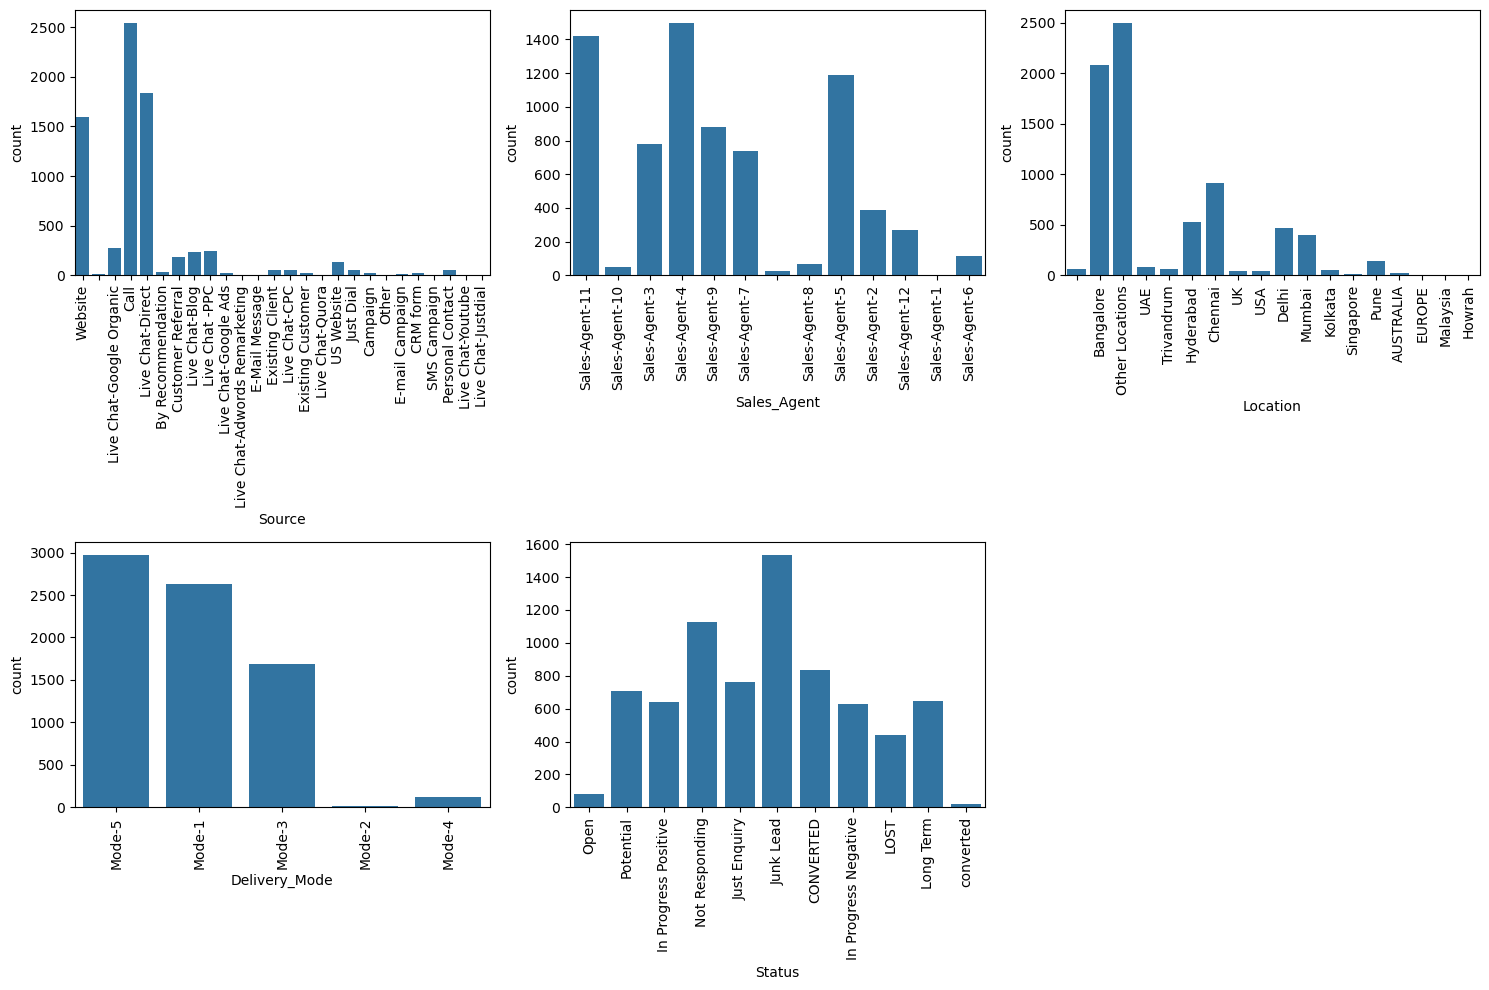

In [13]:
cols = ['Source','Sales_Agent','Location','Delivery_Mode','Status']
plt.figure(figsize=(15,10))
plotnumber = 1
for i in cols:
    plt.subplot(2,3,plotnumber)
    sns.countplot(x= data[i])
    plt.xticks(rotation= 90)
    plotnumber+=1
plt.tight_layout()
plt.show()

## Insights:-

- **Calls and Live Chat – Direct** is the top lead source.
- **Sales-Agent-4** handles the highest number of leads.
- Most leads come from **Other Locations and Bangalore**.
- **Most columns contain missing/invalid values**, which affects data quality and analysis.
- **Mode-5** is the most used delivery mode.
- **Junk Lead is the highest**, while **converted leads are low**.

In [14]:
data.sample(5)

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
4506,07-07-2018 15:40,9,Live Chat-Direct,988XXXXXXX,kXXXXXXX@gmail.com,Sales-Agent-12,Bangalore,Mode-1,Junk Lead
614,25-10-2018 12:36,18,Live Chat-Direct,XXXXXXX,bXXXXXXX@yahoo.com,Sales-Agent-4,Other Locations,Mode-5,Not Responding
4454,09-07-2018 16:51,10,Customer Referral,+97XXXXXXX,nXXXXXXX@gmail.com,Sales-Agent-3,Bangalore,Mode-4,CONVERTED
6159,29-05-2018 16:33,5,Call,,mXXXXXXX@gmail.com,Sales-Agent-4,Mumbai,Mode-3,Junk Lead
6257,28-05-2018 11:07,5,Call,,mXXXXXXX@gmail.com,Sales-Agent-4,Bangalore,Mode-1,Just Enquiry


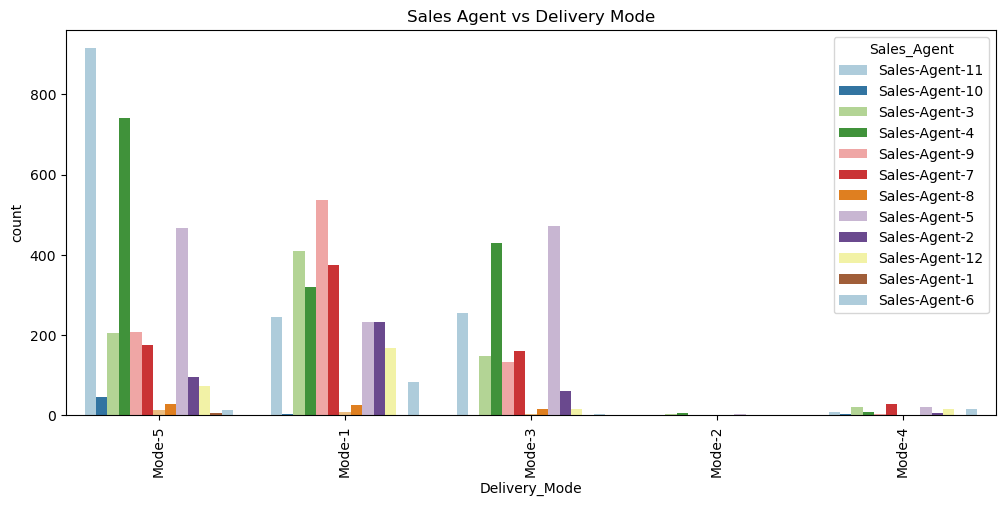

In [15]:
# sales agent vs Delivery mode
plt.figure(figsize=(12,5))
sns.countplot(x="Delivery_Mode", hue="Sales_Agent", data=data, palette="Paired")
plt.xticks(rotation=90)
plt.title("Sales Agent vs Delivery Mode")
plt.show()

### Insights:-
- **Mode-5 is mostly handled by Sales-Agent-11 and Sales-Agent-4**, showing their strong involvement in the most used delivery type.
- **Mode-1 is widely used across many agents**, especially Sales-Agent-9, Sales-Agent-3, and Sales-Agent-7.
- **Mode-3 is dominated by Sales-Agent-5 and Sales-Agent-4**.
- **Mode-2 and Mode-4 have very low usage** by all sales agents.
- Overall, **a few agents handle the majority of deliveries**, indicating an uneven workload.

Text(0.5, 1.0, 'Delivery Mode vs Location')

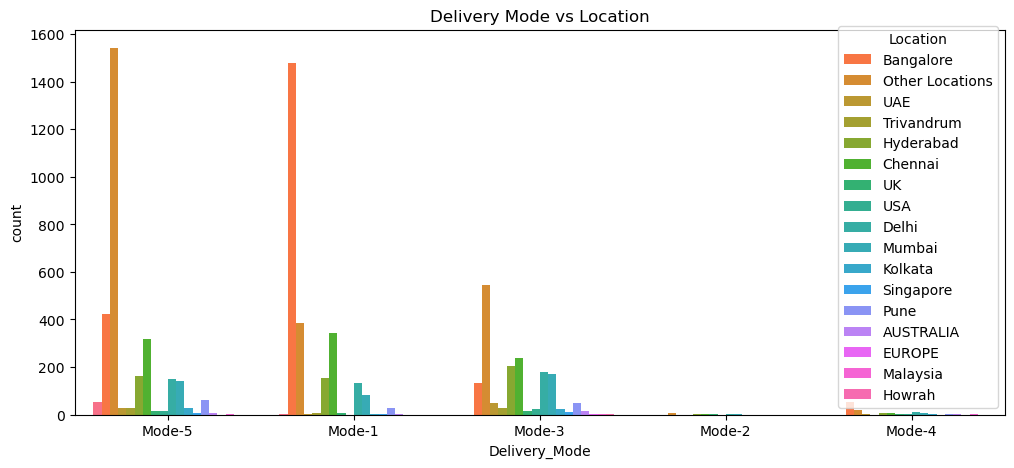

In [16]:
# delivery_mode vs location
plt.figure(figsize=(12,5))
sns.countplot(x='Delivery_Mode',hue='Location',data = data,saturation=2)
plt.title("Delivery Mode vs Location")

### Insights:-

- **Mode-5 is highest in “Other Locations” and Bangalore**, making it the dominant delivery choice in top lead regions.
- **Mode-1 is mainly used in Bangalore**, with good contribution from Other Locations and Hyderabad.
- **Mode-3 also performs well in Other Locations**, followed by Hyderabad and Chennai.
- **Mode-2 and Mode-4 have very low usage across all locations**.
- International locations (UK, USA, UAE, etc.) contribute **very few deliveries**.

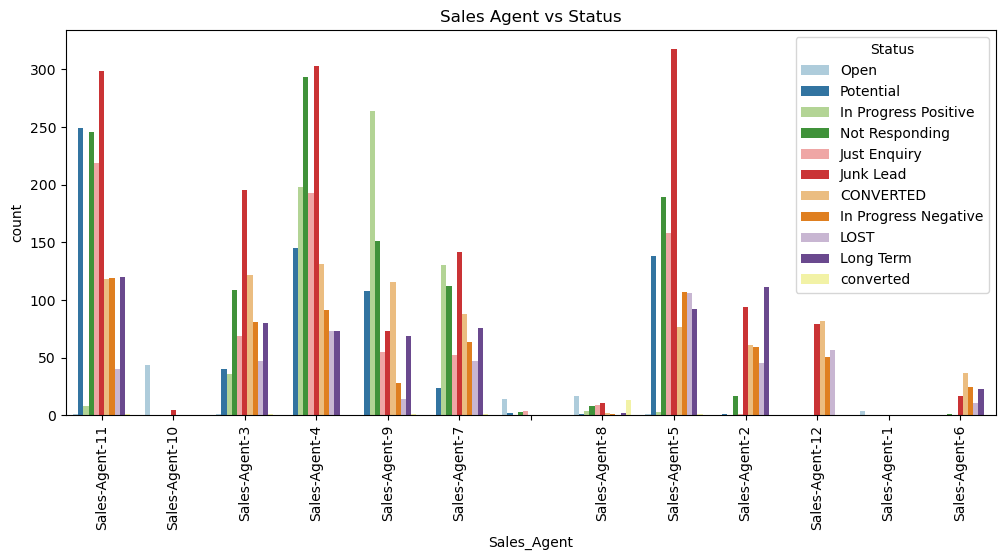

In [17]:
# sales agent vs status
plt.figure(figsize=(12,5))
sns.countplot(x="Sales_Agent", hue="Status", data=data, palette="Paired")
plt.xticks(rotation=90)
plt.title("Sales Agent vs Status")
plt.show()

### Insighs:-

- **Sales-Agent-4, Sales-Agent-5, and Sales-Agent-11 handle the highest number of leads**.
- **Junk Lead is the most common status for almost all agents**, showing poor lead quality.
- **Converted leads are much lower than junk and not responding**, indicating low conversion efficiency.
- **Sales-Agent-9 shows good In-Progress Positive leads**, which means better potential conversions.
- Some agents (like Sales-Agent-10, Sales-Agent-1, Sales-Agent-8) have **very few leads**, showing uneven workload.


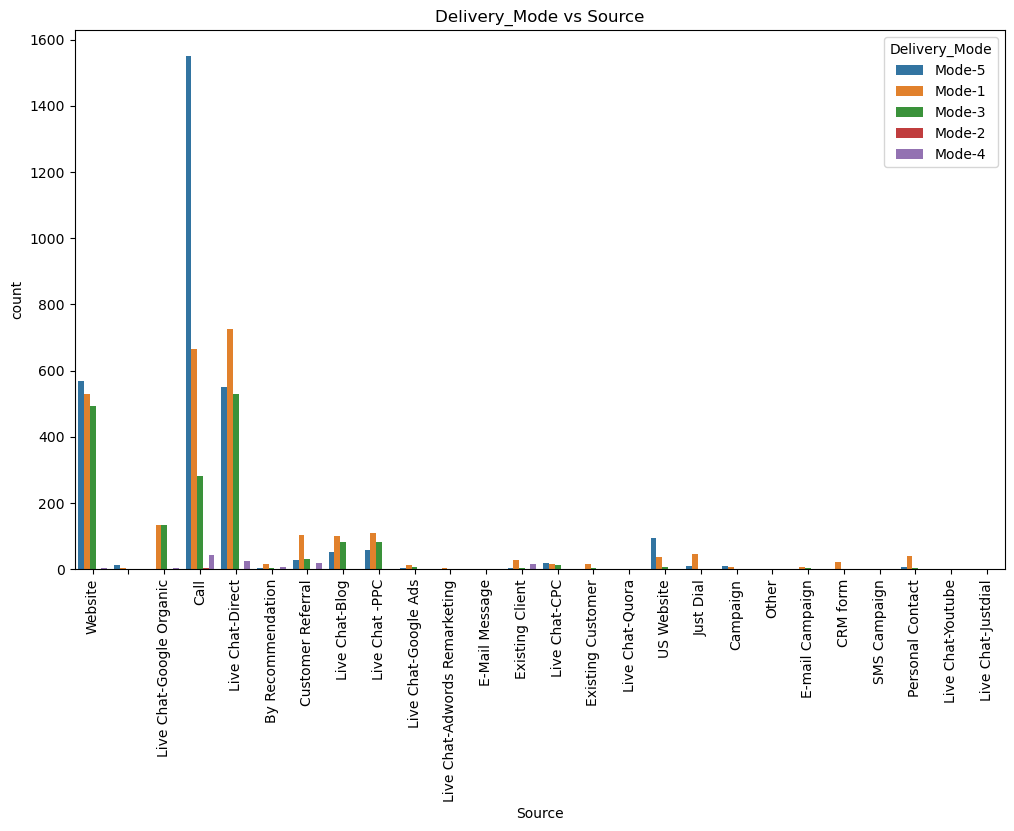

In [18]:
# source vs mode 
plt.figure(figsize=(12,7))
sns.countplot(x="Source",hue = 'Delivery_Mode', data=data)
plt.xticks(rotation=90)
plt.title("Delivery_Mode vs Source")
plt.show()

### Insights:-

- **Call is the biggest lead source**, mainly using **Mode-5**.
- **Live Chat – Direct and Website** also generate high leads, mostly through **Mode-1 and Mode-5**.
- **Mode-3 is moderately used** for Call and Live Chat – Direct.
- **Mode-2 and Mode-4 are rarely used** across all sources.
- Other sources (Referral, Campaigns, Email, SMS, etc.) contribute **very few deliveries**.


# Data PreProcessing

In [19]:
## Checking for missing values

data.isnull().sum()

Created          0
Product_ID       0
Source           0
Mobile           0
EMAIL            0
Sales_Agent      0
Location         0
Delivery_Mode    0
Status           0
dtype: int64

- As we can see that there is not missing value found but some values are having space, so I'm going to replace it with null values to identify.
- Then I will replace that using Imputation method.

In [20]:
# replacing space with the null values
for i in data.columns:
    data[i].replace('',np.nan, inplace =True)

In [21]:
# Now as we can see that there is missing values in most of the columns
data.isnull().sum()

Created             0
Product_ID         58
Source             17
Mobile           1810
EMAIL               0
Sales_Agent        23
Location           58
Delivery_Mode       0
Status              0
dtype: int64

In [22]:
data.sample(2)

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
4925,26-06-2018 17:26,27,Website,967XXXXXXX,LXXXXXXX@gmail.com,Sales-Agent-11,Hyderabad,Mode-5,Junk Lead
4665,03-07-2018 13:01,27,Call,984XXXXXXX,cXXXXXXXdgroup.net,Sales-Agent-9,Bangalore,Mode-1,Long Term


**Product_ID**


In [23]:
data['Product_ID'].value_counts()

Product_ID
18    1711
15    1518
19    1189
9      992
27     739
5      487
10     168
1      105
20     102
25      90
21      66
2       38
12      36
26      31
14      27
11      12
22       8
3        7
17       7
6        7
8        6
13       5
24       3
16       3
23       2
0        2
28       1
7        1
4        1
Name: count, dtype: int64

In [24]:
data.loc[data['Product_ID'].isnull(),'Product_ID'] = 18

In [25]:
data['Product_ID'].isnull().sum()

np.int64(0)

**Source**

In [26]:
data['Source'].value_counts()

Source
Call                             2547
Live Chat-Direct                 1834
Website                          1594
Live Chat-Google Organic          274
Live Chat -PPC                    249
Live Chat-Blog                    237
Customer Referral                 180
US Website                        137
Just Dial                          56
Existing Client                    51
Personal Contact                   50
Live Chat-CPC                      50
By Recommendation                  32
CRM form                           23
Existing Customer                  22
Live Chat-Google Ads               21
Campaign                           19
E-mail Campaign                    12
Live Chat-Adwords Remarketing       7
Live Chat-Quora                     2
Other                               2
SMS Campaign                        2
Live Chat-Youtube                   2
E-Mail Message                      1
Live Chat-Justdial                  1
Name: count, dtype: int64

In [27]:
data.loc[data['Source'].isnull(),'Source'] = 'Call'

In [28]:
data['Source'].isnull().sum()

np.int64(0)

**Mobile**

In [29]:
data['Mobile'].value_counts()

Mobile
XXXXXXX       222
988XXXXXXX    211
984XXXXXXX    177
998XXXXXXX    125
994XXXXXXX    112
             ... 
747XXXXXXX      1
124XXXXXXX      1
031XXXXXXX      1
(31XXXXXXX      1
9535207621      1
Name: count, Length: 486, dtype: int64

In [30]:
data.loc[data["Mobile"].isnull(),"Mobile"] = "XXXXXXX"

In [31]:
data['Mobile'].isnull().sum()

np.int64(0)

**Sales_Agent**

In [32]:
data['Sales_Agent'].value_counts()

Sales_Agent
Sales-Agent-4     1500
Sales-Agent-11    1420
Sales-Agent-5     1190
Sales-Agent-9      879
Sales-Agent-3      781
Sales-Agent-7      736
Sales-Agent-2      389
Sales-Agent-12     269
Sales-Agent-6      114
Sales-Agent-8       68
Sales-Agent-10      49
Sales-Agent-1        4
Name: count, dtype: int64

In [33]:
data.loc[data["Sales_Agent"].isnull(),"Sales_Agent"] = "Sales-Agent-4"

In [34]:
data['Sales_Agent'].isnull().sum()

np.int64(0)

**Location**

In [35]:
data['Location'].value_counts()

Location
Other Locations    2500
Bangalore          2084
Chennai             909
Hyderabad           528
Delhi               471
Mumbai              402
Pune                142
UAE                  79
Trivandrum           58
Kolkata              55
USA                  45
UK                   41
AUSTRALIA            25
Singapore            17
Malaysia              4
EUROPE                3
Howrah                1
Name: count, dtype: int64

In [36]:
data.loc[data["Location"].isnull(),"Location"] = "Other Locations"

In [37]:
data['Location'].isnull().sum()

np.int64(0)

In [38]:
#  All null values has been replaced successfully
data.isnull().sum()

Created          0
Product_ID       0
Source           0
Mobile           0
EMAIL            0
Sales_Agent      0
Location         0
Delivery_Mode    0
Status           0
dtype: int64

In [39]:
# Creating new column for seperate day,month,hours and minutes.
# As we have only one year of data so year will be same for all records that's why I'm ingnoring it.

data["Created_day"] = pd.to_datetime(data.Created).dt.day
data["Created_month"] = pd.to_datetime(data.Created).dt.month
data["Created_hour"] = pd.to_datetime(data.Created).dt.hour
data["Created_min"] = pd.to_datetime(data.Created).dt.minute

In [40]:
data.sample(5)

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status,Created_day,Created_month,Created_hour,Created_min
2724,24-08-2018 15:50,15,Live Chat-Google Ads,982XXXXXXX,eXXXXXXXlacabs.com,Sales-Agent-5,Pune,Mode-5,Junk Lead,24,8,15,50
1809,19-09-2018 13:20,5,Live Chat-Direct,995XXXXXXX,rXXXXXXX@yahoo.com,Sales-Agent-5,Delhi,Mode-3,Potential,19,9,13,20
5226,20-06-2018 10:26,9,Call,918XXXXXXX,kXXXXXXX@gmail.com,Sales-Agent-2,Bangalore,Mode-1,In Progress Negative,20,6,10,26
824,17-10-2018 15:52,15,Website,038XXXXXXX,mXXXXXXXerhelp.com,Sales-Agent-4,Other Locations,Mode-5,Not Responding,17,10,15,52
3045,16-08-2018 10:04,18,Call,965XXXXXXX,lXXXXXXX@gmail.com,Sales-Agent-2,Other Locations,Mode-3,CONVERTED,16,8,10,4


In [41]:
# As we can see that product id is numerical but its show as object 
# so we need to change the datatypes of that columns

data['Product_ID'] = data['Product_ID'].astype(int)

## Label Encoding

In [42]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

data.Source = le.fit_transform(data.Source)
data.Sales_Agent = le.fit_transform(data.Sales_Agent)
data.Location = le.fit_transform(data.Location)

- There is more than 10 unique values in target columns.
- So, based on our business case we need to predict whether status is High Potential or Low Potential.
- So we need to change the unique values into the target variable(High Potential or Low Potential).

In [43]:
# changing variable into High Potential or Low Potential

data.Status.replace(["CONVERTED","Potential","In Progress Positive","converted"],"High Potential",inplace=True)
data.Status.replace(["Junk Lead","Not Responding","Just Enquiry","Long Term","In Progress Negative","LOST","Open"],
                          "Low potential",inplace=True)

In [44]:
data.Delivery_Mode.unique()

array(['Mode-5', 'Mode-1', 'Mode-3', 'Mode-2', 'Mode-4'], dtype=object)

In [45]:
# Applying One hot encoding on Delivery_Mode

data = pd.get_dummies(data, columns=['Delivery_Mode'], drop_first=True, dtype=int)

In [46]:
# Applying Manual Encoding in target columns

data['Status'].replace({'High Potential':1,'Low potential':0},inplace =True)

In [47]:
data['Status'].unique()

array([0, 1])

In [48]:
data.head()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Status,Created_day,Created_month,Created_hour,Created_min,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5
0,14-11-2018 10:05,18,24,984XXXXXXX,aXXXXXXX@gmail.com,2,10,0,14,11,10,5,0,0,0,1
1,14-11-2018 09:22,18,24,XXXXXXX,#VALUE!,1,10,0,14,11,9,22,0,0,0,1
2,14-11-2018 09:21,18,24,XXXXXXX,dXXXXXXX@yahoo.com,1,10,0,14,11,9,21,0,0,0,1
3,14-11-2018 08:46,18,24,XXXXXXX,wXXXXXXX@gmail.com,1,10,0,14,11,8,46,0,0,0,1
4,14-11-2018 07:34,18,24,XXXXXXX,cXXXXXXX@gmail.com,1,10,0,14,11,7,34,0,0,0,1


In [49]:
## Dropping Unnecessory columns

data.drop(columns=['Created','Mobile','EMAIL'],axis= 1, inplace =True)

In [50]:
data.head()

,Product_ID,Source,Sales_Agent,Location,Status,Created_day,Created_month,Created_hour,Created_min,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5
0,18,24,2,10,0,14,11,10,5,0,0,0,1
1,18,24,1,10,0,14,11,9,22,0,0,0,1
2,18,24,1,10,0,14,11,9,21,0,0,0,1
3,18,24,1,10,0,14,11,8,46,0,0,0,1
4,18,24,1,10,0,14,11,7,34,0,0,0,1


# Feature Selection

<Axes: >

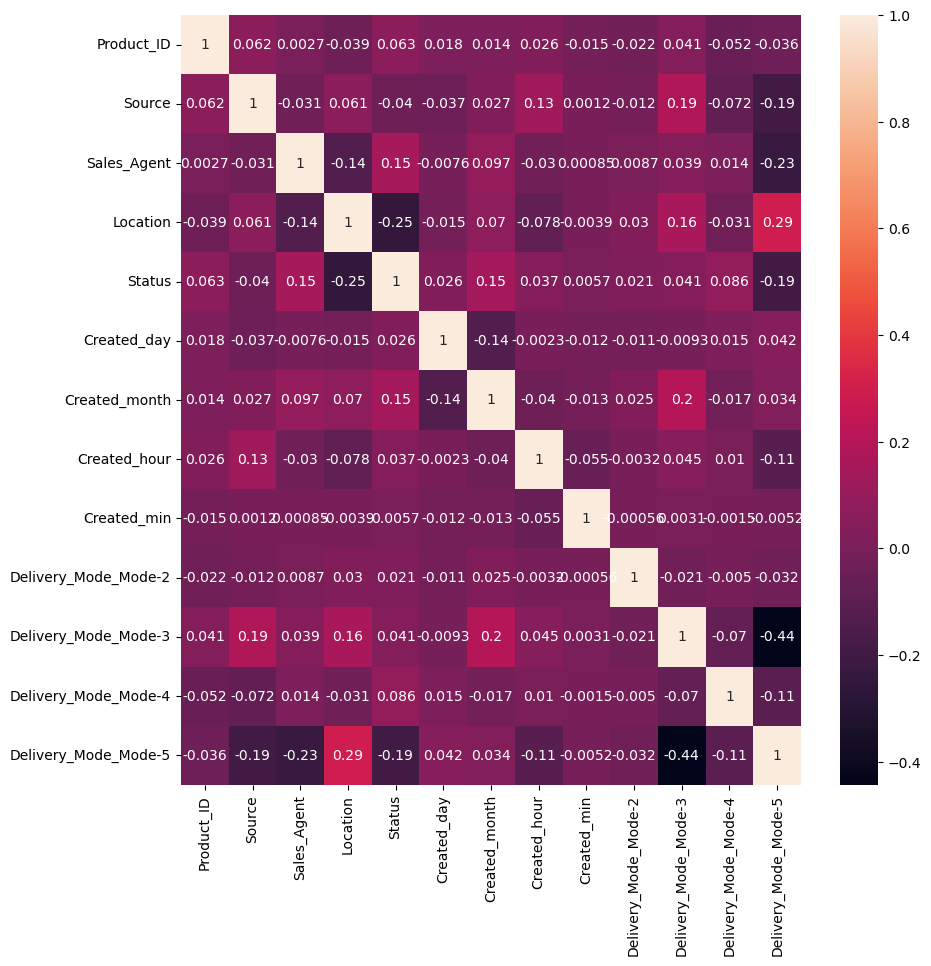

In [51]:
# Plotting heatmap to see the correlation between the columns

plt.figure(figsize=(10,10))
sns.heatmap(data.corr(),annot=True)

- As we can see that the **Created_min** is very less corelated with the target columns.
- So I'm dropping **Created_min** column.

In [52]:
data.drop('Created_min',axis= 1,inplace =True)

In [53]:
data.columns

Index(['Product_ID', 'Source', 'Sales_Agent', 'Location', 'Status',
       'Created_day', 'Created_month', 'Created_hour', 'Delivery_Mode_Mode-2',
       'Delivery_Mode_Mode-3', 'Delivery_Mode_Mode-4', 'Delivery_Mode_Mode-5'],
      dtype='object')

- Now Our Dataset is clean and ready for model building.

## Split the data into X and Y

In [54]:
X = data.drop('Status',axis=1)
Y = data['Status']

# Model Creation

In [55]:
# Dividing data for training and testing

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.25,random_state=9)


In [56]:
x_train

,Product_ID,Source,Sales_Agent,Location,Created_day,Created_month,Created_hour,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5
6646,15,2,11,10,17,5,10,0,0,0,1
107,18,24,11,9,11,11,18,0,1,0,0
6559,9,2,9,1,19,5,12,0,0,0,0
6977,9,2,2,1,8,5,18,0,0,0,1
4362,27,2,6,2,11,7,16,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6200,18,14,4,9,29,5,11,0,0,0,0
501,15,2,2,10,29,10,11,0,0,0,1
6782,15,2,5,10,14,5,10,0,0,0,1
4444,1,16,7,2,9,7,20,0,1,0,0


In [57]:
x_test

,Product_ID,Source,Sales_Agent,Location,Created_day,Created_month,Created_hour,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5
4665,27,2,11,1,3,7,13,0,0,0,0
5540,18,2,9,1,13,6,10,0,0,0,0
3496,15,2,7,10,3,8,11,0,0,0,1
1267,18,2,11,1,4,10,10,0,0,0,0
2460,27,14,4,1,1,9,15,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6121,18,10,5,10,30,5,11,0,0,0,0
2789,9,2,11,1,23,8,10,0,0,0,0
3365,18,2,11,1,7,8,12,0,0,0,1
6117,27,10,7,1,30,5,13,0,0,0,0


## Balancing the Data

In [58]:
from imblearn.over_sampling import SMOTE
sm = SMOTE()
x_smote,y_smote = sm.fit_resample(x_train,y_train)

In [59]:
# checking data balanced or not
from collections import Counter
print(Counter(y_train))
print(Counter(y_smote))


Counter({0: 3895, 1: 1671})
Counter({0: 3895, 1: 3895})


# Model Selection

## Logistic Regression

In [60]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_smote,y_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [61]:
# Prediction

lr_pred = lr.predict(x_test)
lr_pred

array([1, 1, 0, ..., 0, 1, 0], shape=(1856,))

In [62]:
# Evaluating our model
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,classification_report
lr_acc = accuracy_score(lr_pred,y_test)
lr_acc

0.6837284482758621

In [119]:
lr_f1 = f1_score(lr_pred,y_test,average='weighted')
lr_f1

0.6734528935694495

In [120]:
confusion_matrix(lr_pred,y_test)

array([[953, 216],
       [371, 316]])

In [121]:
print(classification_report(lr_pred,y_test))

              precision    recall  f1-score   support

           0       0.72      0.82      0.76      1169
           1       0.59      0.46      0.52       687

    accuracy                           0.68      1856
   macro avg       0.66      0.64      0.64      1856
weighted avg       0.67      0.68      0.67      1856



### Hyperparamter Tuning

In [114]:
# Import required libraries
from sklearn.model_selection import RandomizedSearchCV

# Define hyperparameter distributions
param_dist = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],   # Regularization strength values
    'penalty': ['l1', 'l2'],              # Regularization types
    'solver': ['liblinear'],              # Solver supporting l1 and l2
    'class_weight': [None, 'balanced']    # Handle class imbalance
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=lr,        # Model to tune
    param_distributions=param_dist,  # Parameter distributions
    n_iter=20,                # Number of random combinations to try
    scoring='f1_weighted',    # Evaluation metric
    verbose = 2,              # Printing statement
    cv=2,                     # 5-fold cross-validation
    random_state=42,          # Reproducibility
    n_jobs=-1                 # Use all CPU cores
)

# Fit RandomizedSearchCV on training data
random_search.fit(x_smote, y_smote)

# Get the best tuned model
best_log_reg = random_search.best_estimator_

# Print best hyperparameters
print("Best Hyperparameters:", random_search.best_params_)


Fitting 2 folds for each of 20 candidates, totalling 40 fits
Best Hyperparameters: {'solver': 'liblinear', 'penalty': 'l2', 'class_weight': None, 'C': 0.01}


In [115]:
# Build model with the best hyperparameters

lr1 = LogisticRegression(solver='liblinear',penalty = 'l2',class_weight=None,C=0.01)
lr1.fit(x_smote,y_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [116]:
# prediction

lr1_pred = lr1.predict(x_test)
lr1_pred

array([1, 1, 0, ..., 1, 1, 1], shape=(1856,))

In [122]:
lr1_acc = accuracy_score(y_test,lr1_pred)
lr1_f1 = f1_score(y_test,lr1_pred,average='weighted')

In [123]:
lr1_acc

0.6740301724137931

In [124]:
lr1_f1

0.6860087558027391

In [125]:
print(classification_report(lr1_pred,y_test))

              precision    recall  f1-score   support

           0       0.70      0.82      0.75      1137
           1       0.61      0.45      0.52       719

    accuracy                           0.67      1856
   macro avg       0.65      0.63      0.64      1856
weighted avg       0.66      0.67      0.66      1856



## Support Vector Machine



In [66]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(x_smote,y_smote)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [67]:
svc_pred = svc.predict(x_test)
svc_pred

array([1, 1, 0, ..., 1, 1, 1], shape=(1856,))

In [68]:
svc_acc = accuracy_score(svc_pred,y_test)
svc_acc

0.6745689655172413

In [188]:
svc_f1 = f1_score(svc_pred,y_test,average='weighted')
svc_f1

0.6607842368432477

In [70]:
confusion_matrix(svc_pred,y_test)

array([[901, 181],
       [423, 351]])

In [71]:
print(classification_report(svc_pred,y_test))

              precision    recall  f1-score   support

           0       0.68      0.83      0.75      1082
           1       0.66      0.45      0.54       774

    accuracy                           0.67      1856
   macro avg       0.67      0.64      0.64      1856
weighted avg       0.67      0.67      0.66      1856



### HyperParameter Tuning

In [140]:
# Define hyperparameter grid for RandomizedSearchCV

from sklearn.svm import SVC
model = SVC()                 # initialize the model

from sklearn.model_selection import RandomizedSearchCV
param_grid = {'C':[0.1,0.5,10,30,60,85,100],           # Regularization strength values to try
             'gamma':[0.1,0.001,0.0001,1],             # Kernel coefficient values for RBF/Sigmoid kernels
             'random_state': (list(range(1,20)))}      # Different random seeds to test model stability
r_model = RandomizedSearchCV(model,param_distributions=param_grid,verbose=2,scoring='accuracy',cv=5,refit=True)       ## Initialize the RandomizedSearchCV
r_model.fit(x_smote,y_smote)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ................C=0.1, gamma=0.0001, random_state=9; total time=  12.2s
[CV] END ................C=0.1, gamma=0.0001, random_state=9; total time=  12.0s
[CV] END ................C=0.1, gamma=0.0001, random_state=9; total time=  11.8s
[CV] END ................C=0.1, gamma=0.0001, random_state=9; total time=  11.8s
[CV] END ................C=0.1, gamma=0.0001, random_state=9; total time=  12.0s
[CV] END .................C=60, gamma=0.001, random_state=17; total time=  10.2s
[CV] END .................C=60, gamma=0.001, random_state=17; total time=  10.5s
[CV] END .................C=60, gamma=0.001, random_state=17; total time=  10.9s
[CV] END .................C=60, gamma=0.001, random_state=17; total time=  10.9s
[CV] END .................C=60, gamma=0.001, random_state=17; total time=  10.4s
[CV] END .....................C=100, gamma=1, random_state=9; total time=  12.5s
[CV] END .....................C=100, gamma=1, ra

,estimator,SVC()
,param_distributions,"{'C': [0.1, 0.5, ...], 'gamma': [0.1, 0.001, ...], 'random_state': [1, 2, ...]}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [141]:
print(r_model.best_params_)        ## checking best parameters

{'random_state': 1, 'gamma': 0.1, 'C': 85}


In [142]:
svc1 = SVC(C=85, gamma=0.1,random_state=1) ## use best parameters for best score
svc1.fit(x_smote,y_smote)

,C,85
,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [143]:
# Testing the model
svc1_pred = svc1.predict(x_test)
svc1_pred

array([1, 1, 0, ..., 0, 0, 1], shape=(1856,))

In [145]:
## Accuracy Score
svc1_acc = accuracy_score(y_test,svc1_pred)
svc1_acc

0.7068965517241379

In [146]:
## Checking F1 score
svc1_f1 = f1_score(y_test,svc1_pred,average='weighted')
svc1_f1

0.7007686503543514

In [148]:
print(classification_report(y_test,svc1_pred))

              precision    recall  f1-score   support

           0       0.78      0.82      0.80      1324
           1       0.49      0.43      0.45       532

    accuracy                           0.71      1856
   macro avg       0.63      0.62      0.63      1856
weighted avg       0.70      0.71      0.70      1856



## Decision Tree

In [72]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_smote,y_smote)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [73]:
dt_pred = dt.predict(x_test)
dt_pred

array([1, 0, 0, ..., 0, 0, 0], shape=(1856,))

In [74]:
dt_acc = accuracy_score(dt_pred,y_test)
dt_acc

0.6600215517241379

In [187]:
dt_f1 = f1_score(dt_pred,y_test,average='weighted')
dt_f1

0.6510390154608188

In [76]:
confusion_matrix(dt_pred,y_test)

array([[950, 257],
       [374, 275]])

In [77]:
print(classification_report(dt_pred,y_test))

              precision    recall  f1-score   support

           0       0.72      0.79      0.75      1207
           1       0.52      0.42      0.47       649

    accuracy                           0.66      1856
   macro avg       0.62      0.61      0.61      1856
weighted avg       0.65      0.66      0.65      1856



### Hyperparameter tuning

In [134]:
## crearing dictionary for hyperparameters
from sklearn.model_selection import RandomizedSearchCV
params = {'criterion':('gini','entropy'),          # Methods to measure quality of a split
         'splitter':('random','best'),             # To choose split at each node
         'max_depth':(list(range(1,30))),          # Maximum height of the tree
         'min_samples_split':[2,5,7,10],           # Minimum samples required to split an internal node
         'min_samples_leaf':list(range(1,20))}     # Minimum samples required in a leaf node

tree_clf = DecisionTreeClassifier(random_state=9)
tree_hy = RandomizedSearchCV(tree_clf,params,scoring='accuracy',n_jobs=1,verbose=3,cv=10)       ## Initialize the GridSearchCV


# verbose=2 = show training progress in a clean, readable way.
#n_jobs = -1 =  use all CPU cores to make training faster.

tree_hy.fit(x_smote,y_smote)                    ## fit a data for hyperparameter tuning
best_params = tree_hy.best_params_             ## Best Parameters given by using hyperparameter tuning
print(f"Best Parameters: {best_params}")       ## Printing the best parameters

Fitting 10 folds for each of 10 candidates, totalling 100 fits
[CV 1/10] END criterion=entropy, max_depth=5, min_samples_leaf=19, min_samples_split=10, splitter=best;, score=0.624 total time=   0.0s
[CV 2/10] END criterion=entropy, max_depth=5, min_samples_leaf=19, min_samples_split=10, splitter=best;, score=0.660 total time=   0.0s
[CV 3/10] END criterion=entropy, max_depth=5, min_samples_leaf=19, min_samples_split=10, splitter=best;, score=0.674 total time=   0.0s
[CV 4/10] END criterion=entropy, max_depth=5, min_samples_leaf=19, min_samples_split=10, splitter=best;, score=0.661 total time=   0.0s
[CV 5/10] END criterion=entropy, max_depth=5, min_samples_leaf=19, min_samples_split=10, splitter=best;, score=0.728 total time=   0.0s
[CV 6/10] END criterion=entropy, max_depth=5, min_samples_leaf=19, min_samples_split=10, splitter=best;, score=0.736 total time=   0.0s
[CV 7/10] END criterion=entropy, max_depth=5, min_samples_leaf=19, min_samples_split=10, splitter=best;, score=0.774 tota

In [135]:
dt1 = DecisionTreeClassifier(criterion='gini',max_depth=13,min_samples_split=5,min_samples_leaf=3,splitter='random')
dt1.fit(x_smote,y_smote)

,criterion,'gini'
,splitter,'random'
,max_depth,13
,min_samples_split,5
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [136]:
dt1_pred = dt1.predict(x_test)
dt1_pred

array([1, 1, 0, ..., 0, 0, 0], shape=(1856,))

In [137]:
## checking accuracy by using hyperparameter tuning
dt1_acc = accuracy_score(y_test,dt1_pred)
dt1_acc

0.693426724137931

In [138]:
dt1_f1 = f1_score(y_test,dt1_pred,average='weighted')
dt1_f1

0.7014190247159304

In [139]:
print(classification_report(dt1_pred,y_test))

              precision    recall  f1-score   support

           0       0.74      0.81      0.78      1209
           1       0.57      0.47      0.52       647

    accuracy                           0.69      1856
   macro avg       0.66      0.64      0.65      1856
weighted avg       0.68      0.69      0.69      1856



## Random Forest

In [78]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_smote,y_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [79]:
rf_pred = rf.predict(x_test)
rf_pred

array([1, 1, 0, ..., 0, 0, 0], shape=(1856,))

In [80]:
rf_acc = accuracy_score(rf_pred, y_test)
rf_acc

0.7262931034482759

In [189]:
rf_f1 = f1_score(rf_pred, y_test,average='weighted')
rf_f1

0.7249530682779608

In [82]:
confusion_matrix(rf_pred, y_test)

array([[1061,  245],
       [ 263,  287]])

In [83]:
print(classification_report(rf_pred, y_test))

              precision    recall  f1-score   support

           0       0.80      0.81      0.81      1306
           1       0.54      0.52      0.53       550

    accuracy                           0.73      1856
   macro avg       0.67      0.67      0.67      1856
weighted avg       0.72      0.73      0.72      1856



### Hyperparameter tuning

In [149]:
# Define hyperparameter grid for RandomizedSearchCV 

from sklearn.model_selection import RandomizedSearchCV

n_estimators = [int(x) for x in np.linspace(200,2000,10)]   ## list comprehension for total number of estimators
max_features = ['auto','sqrt']         ## maximum number of features allowed to try in individual tree 
max_depth = [int(x) for x in np.linspace(10,200,10)]     ## maximum number of height of tree
min_samples_split = [2,5,10,20]        ## minimum number of samples to be present in internal node
min_samples_leaf = [1,2,5,9]         ## minimum number of samples to be present in a leaf node
bootstrap = [True,False]   # Sampling with replacement or not

In [150]:
# dictionary for hyperparameters

from sklearn.ensemble import RandomForestClassifier
random_grid = {'n_estimators':n_estimators,'max_features':max_features,'max_depth':max_depth,
              'min_samples_split':min_samples_split,'min_samples_leaf':min_samples_leaf,'bootstrap':bootstrap}

rf1 = RandomForestClassifier(random_state=39)
rf_hy = RandomizedSearchCV(estimator=rf1,scoring='accuracy',param_distributions=random_grid,n_iter=100,
                           cv=5,verbose=3,random_state=49,n_jobs=1)

# estimators ---> numberr of decision tree
# scoring -----> to measure the performance
# param_distribution -----> hyperparameters values 
# n_iter ------> no.of iteration
# cv ----> totla numberr of folds
# verbose --------> it will prints messages
# n_jobs -----> number of jobs means processor and -1 indicates all processor run in parallel


rf_hy.fit(x_smote,y_smote)                      ## it is used to fit training data on randomsearch cv
rf_best_params = rf_hy.best_params_                ## it is used to give best parameters
print(f"Best Parameters: {rf_best_params}")        ## printing best parameters


Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5] END bootstrap=False, max_depth=136, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=2000;, score=0.710 total time=  34.6s
[CV 2/5] END bootstrap=False, max_depth=136, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=2000;, score=0.730 total time=  34.1s
[CV 3/5] END bootstrap=False, max_depth=136, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=2000;, score=0.816 total time=  35.5s
[CV 4/5] END bootstrap=False, max_depth=136, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=2000;, score=0.857 total time=  36.2s
[CV 5/5] END bootstrap=False, max_depth=136, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=2000;, score=0.835 total time=  34.9s
[CV 1/5] END bootstrap=True, max_depth=73, max_features=auto, min_samples_leaf=1, min_samples_split=10, n_estimators=1800;, score=nan total time=   0.0s

In [151]:
rf2 = RandomForestClassifier(n_estimators= 200, min_samples_split=2, min_samples_leaf=1, max_features= 'sqrt', max_depth= 200, bootstrap= False)
rf2.fit(x_smote,y_smote)

,n_estimators,200
,criterion,'gini'
,max_depth,200
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [152]:
## Predicting
rf2_pred = rf2.predict(x_test) 
rf2_pred

array([1, 1, 0, ..., 0, 0, 0], shape=(1856,))

In [153]:
## Accuracy Score
rf2_acc = accuracy_score(y_test,rf2_pred)
rf2_acc

0.7225215517241379

In [157]:
# F1 Score
rf2_f1 = f1_score(y_test,rf2_pred,average='weighted')
rf2_f1

0.7232121005902219

In [158]:
# Classification Report
print(classification_report(y_test,rf2_pred))

              precision    recall  f1-score   support

           0       0.81      0.80      0.80      1324
           1       0.52      0.52      0.52       532

    accuracy                           0.72      1856
   macro avg       0.66      0.66      0.66      1856
weighted avg       0.72      0.72      0.72      1856



## KNN

In [160]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_smote,y_smote)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [161]:
# Prediction
knn_pred = knn.predict(x_test)
knn_pred

array([1, 1, 0, ..., 1, 0, 1], shape=(1856,))

In [162]:
# Accuracy Score
knn_acc = accuracy_score(y_test,knn_pred)
knn_acc

0.650323275862069

In [163]:
## F1 Score
knn_f1 = f1_score(y_test,knn_pred,average='weighted')
knn_f1

0.6647370000982192

In [164]:
# to find optimal number of k 
# we check how much error given the k in the range of 1 to 10

from sklearn.neighbors import KNeighborsClassifier
error_rate = []

for i in range(1,10):
    KNN = KNeighborsClassifier(n_neighbors=i)
    KNN.fit(x_smote,y_smote)
    KNN_pred = KNN.predict(x_test)
    error_rate.append(np.mean(KNN_pred != y_test))

In [165]:
error_rate

[np.float64(0.3232758620689655),
 np.float64(0.28933189655172414),
 np.float64(0.33620689655172414),
 np.float64(0.30495689655172414),
 np.float64(0.34967672413793105),
 np.float64(0.3238146551724138),
 np.float64(0.3588362068965517),
 np.float64(0.3286637931034483),
 np.float64(0.359375)]

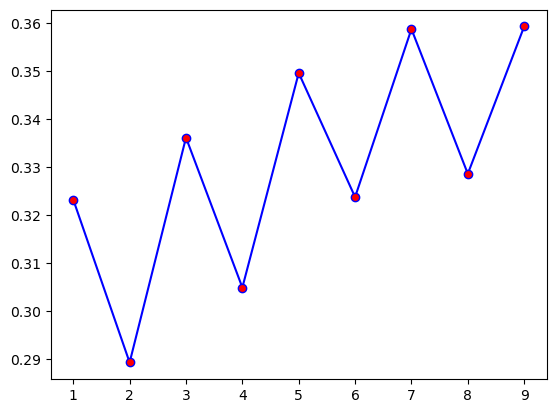

In [166]:
plt.plot(range(1,10),error_rate,color='blue',marker='o',markerfacecolor='red')

In [167]:
# build model using different neighbors very less error 
from sklearn.neighbors import KNeighborsClassifier
knn1 = KNeighborsClassifier(n_neighbors=3)     # Initialize the model
knn1.fit(x_smote,y_smote)                       # fit the data into the model

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [168]:
knn1_pred = knn1.predict(x_test)
knn1_pred

array([1, 1, 0, ..., 1, 0, 1], shape=(1856,))

In [169]:
knn1_acc = accuracy_score(y_test,knn1_pred)
knn1_acc

0.6637931034482759

In [170]:
knn1_f1 = f1_score(y_test,knn1_pred,average='weighted')
knn1_f1

0.6771620381437273

In [171]:
print(classification_report(y_test,knn1_pred))

              precision    recall  f1-score   support

           0       0.82      0.68      0.74      1324
           1       0.44      0.61      0.51       532

    accuracy                           0.66      1856
   macro avg       0.63      0.65      0.63      1856
weighted avg       0.71      0.66      0.68      1856



## XGBoost

In [84]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(x_smote,y_smote)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [85]:
xgb_pred = xgb.predict(x_test)
xgb_pred

array([1, 1, 0, ..., 1, 0, 0], shape=(1856,))

In [86]:
xgb_acc = accuracy_score(xgb_pred,y_test)
xgb_acc

0.7289870689655172

In [190]:
xgb_f1 = f1_score(xgb_pred,y_test,average='weighted')
xgb_f1

0.7247146520343034

In [88]:
confusion_matrix(xgb_pred,y_test)

array([[1041,  220],
       [ 283,  312]])

In [89]:
print(classification_report(xgb_pred,y_test))

              precision    recall  f1-score   support

           0       0.79      0.83      0.81      1261
           1       0.59      0.52      0.55       595

    accuracy                           0.73      1856
   macro avg       0.69      0.67      0.68      1856
weighted avg       0.72      0.73      0.72      1856



### Hyperparameter tuning

In [173]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'min_child_weight': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=50,               # Number of combinations to try
    scoring='f1',            # Better than accuracy for balanced classification
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_smote, y_smote)

print("Best Parameters:")
print(random_search.best_params_)


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters:
{'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 1.0}


In [174]:
# Evaluate
best_model = random_search.best_estimator_

In [179]:
xgb1_pred = best_model.predict(x_test)

xgb1_acc = accuracy_score(y_test, xgb1_pred)
xgb1_acc

0.7176724137931034

In [180]:
xgb1_f1 = f1_score(y_test, xgb1_pred,average='weighted')
xgb1_f1

0.7202075045652677

In [177]:
print("\nClassification Report:\n", classification_report(y_test, xgb1_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.79      0.80      1324
           1       0.51      0.54      0.52       532

    accuracy                           0.72      1856
   macro avg       0.66      0.66      0.66      1856
weighted avg       0.72      0.72      0.72      1856



## ANN

In [110]:
from sklearn.neural_network import MLPClassifier   # Import MLPClassifier for building an Artificial Neural Network

# Initialize the ANN model with specified parameters
ann = MLPClassifier(
    hidden_layer_sizes=(100, 50, 30),   # Define 3 hidden layers with 100, 50, and 30 neurons respectively
    learning_rate_init=0.01,             # Set the initial learning rate for weight updates
    max_iter=100,                        # Set the maximum number of training iterations (epochs)
    random_state=54                       # Set random state for reproducibility of results
)

# Train the ANN model using SMOTE-balanced training data
ann.fit(x_smote, y_smote)

,hidden_layer_sizes,"(100, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.01
,power_t,0.5
,max_iter,100
,shuffle,True
,random_state,54


In [111]:
ann_pred = ann.predict(x_test)
ann_pred

array([1, 1, 0, ..., 0, 0, 0], shape=(1856,))

In [112]:
ann_acc = accuracy_score(ann_pred,y_test)
ann_acc

0.6740301724137931

In [191]:
ann_f1 = f1_score(ann_pred,y_test,average='weighted')
ann_f1

0.6634395240366556

# Model Comaprision Report

In [192]:
# creating model comparison report using DataFrame
score = pd.DataFrame({"Models":["LogisticRegression","RandomForestClassifier","KNeighborsClassifier","DecisionTreeClassifier",'SupportVectorClassifier','XGBoostClassifier',"ANN"],
                     "Accuracy":[lr_acc*100,rf_acc*100,knn_acc*100,dt_acc*100,svc_acc*100,xgb_acc*100,ann_acc*100],
                      "f1_score":[lr_f1*100,rf_f1*100,knn_f1*100,dt_f1*100,svc_f1*100,xgb_f1*100,ann_f1*100],
                     "With Hyperparameter Tunning":[lr1_acc*100,rf2_acc*100,knn1_acc*100,dt1_acc*100,svc1_acc*100,xgb1_acc*100,'-']
                     })

In [193]:
score

,Models,Accuracy,f1_score,With Hyperparameter Tunning
0,LogisticRegression,68.372845,67.345289,67.403017
1,RandomForestClassifier,72.629310,72.495307,72.252155
2,KNeighborsClassifier,65.032328,66.473700,66.37931
3,DecisionTreeClassifier,66.002155,65.103902,69.342672
4,SupportVectorClassifier,70.689655,66.078424,70.689655
5,XGBoostClassifier,72.898707,72.471465,71.767241
6,ANN,67.403017,66.343952,-


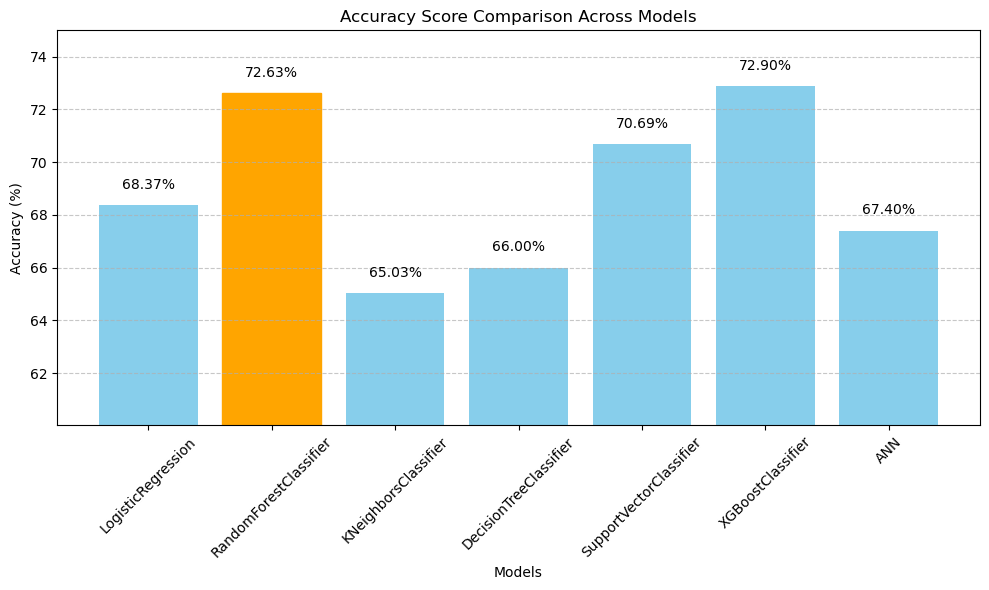

In [194]:
import matplotlib.pyplot as plt

# Plot F1 scores
plt.figure(figsize=(10, 6))
bars = plt.bar(score["Models"], score["Accuracy"], color="skyblue")

# Highlight the best model
best_index = score["f1_score"].idxmax()
bars[best_index].set_color("orange")

# Labels and title
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Score Comparison Across Models")
plt.ylim(min(score["Accuracy"]) - 5, 75)

# Annotate each bar with its value
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{height:.2f}%", 
             ha="center", va="bottom")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

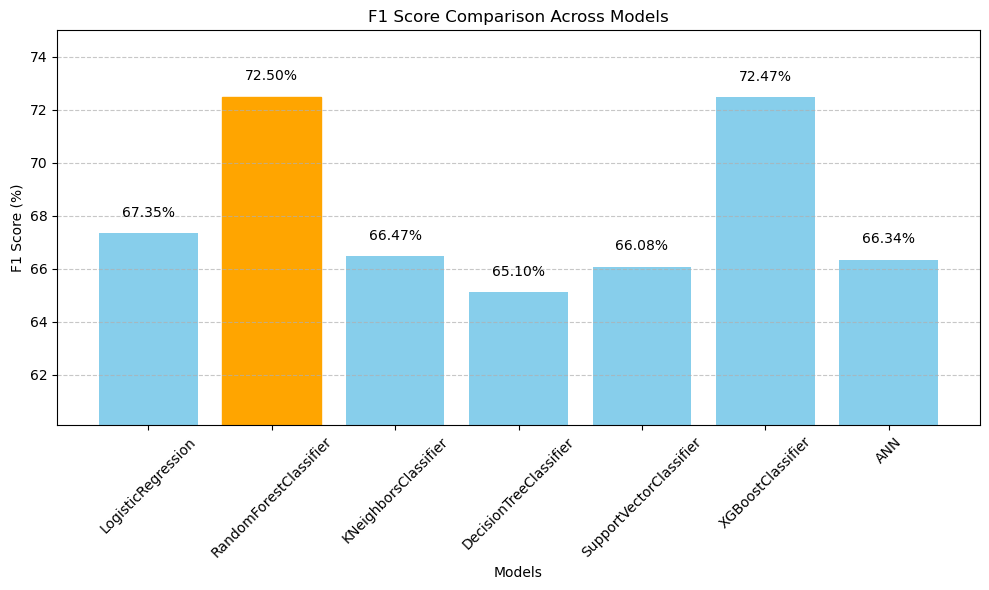

In [195]:
import matplotlib.pyplot as plt

# Plot F1 scores
plt.figure(figsize=(10, 6))
bars = plt.bar(score["Models"], score["f1_score"], color="skyblue")

# Highlight the best model
best_index = score["f1_score"].idxmax()
bars[best_index].set_color("orange")

# Labels and title
plt.xlabel("Models")
plt.ylabel("F1 Score (%)")
plt.title("F1 Score Comparison Across Models")
plt.ylim(min(score["f1_score"]) - 5, 75)

# Annotate each bar with its value
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{height:.2f}%", 
             ha="center", va="bottom")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

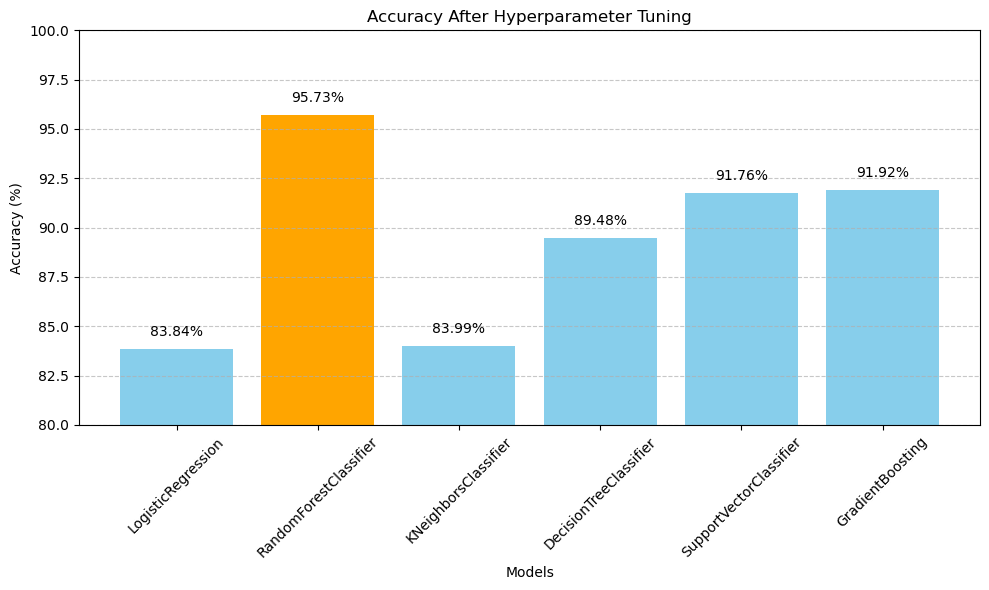

In [196]:
# Data
models = [
    'LogisticRegression',
    'RandomForestClassifier',
    'KNeighborsClassifier',
    'DecisionTreeClassifier',
    'SupportVectorClassifier',
    'GradientBoosting'
]
accuracy = [83.84, 95.73, 83.99, 89.48, 91.76, 91.92]

# Highlight best model
best_index = accuracy.index(max(accuracy))
colors = ['skyblue'] * len(models)
colors[best_index] = 'orange'  # Highlight best model

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracy, color=colors)
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy After Hyperparameter Tuning')
plt.ylim(80, 100)

# Annotate bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{height:.2f}%', ha='center', va='bottom')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 🔎 Models Evaluated

| Model                     | Accuracy (%) | F1 Score (%) | After Hyperparameter Tuning (%) |
|----------------------------|-------------|--------------|----------------------------------|
| Logistic Regression        | 68.37       | 67.34        | 67.40                           |
| Random Forest Classifier   | 72.63       | 72.49        | 72.25                           |
| K-Nearest Neighbors        | 65.03       | 66.47        | 66.38                           |
| Decision Tree              | 66.00       | 65.10        | 69.34                           |
| Support Vector Classifier  | 70.69       | 66.07        | 70.69                           |
| XGBoost Classifier         | 72.90       | 72.47        | 71.77                           |
| Artificial Neural Network  | 67.40       | 66.34        | —                               |


##  Key Insights

- **XGBoost achieved the highest Accuracy (72.90%) and highest F1 Score (72.47%)**.
- **Random Forest performed very close to XGBoost**, making it a strong alternative.
- **Decision Tree improved significantly after tuning**.
- **KNN and ANN showed comparatively lower performance**.
- Logistic Regression provided stable but moderate results.
- Hyperparameter tuning improved performance in some models (especially Decision Tree).



##  Recommended Model: **XGBoost Classifier**

###  Why XGBoost?
- Highest overall performance (Accuracy + F1 Score)
- Handles non-linear relationships effectively
- Built-in regularization reduces overfitting
- Performs very well on structured/tabular sales data


##  Final Conclusion

For predicting **sales conversion (Status)** in this project,  
**XGBoost is the best-performing and most reliable model**,  
with Random Forest as a strong backup option.

                                                            --DONE--